# Bài Tập Thực Hành: Xây Dựng CNN (ShallowNet)



## Phần 1: Chuẩn Bị Môi Trường và Hiểu Cấu Hình Keras

### Bước 1.1: Kiểm tra file cấu hình `keras.json`
- **Tham khảo**: Trang 1, mục 12.1.1
- **Nhiệm vụ**: Tìm và mở file `~/.keras/keras.json`, ghi chép 4 thông số chính,
  giải thích sự khác biệt giữa `channels_last` và `channels_first`.


In [2]:
# Bước 1.1: Đọc và hiển thị nội dung file cấu hình keras.json
import os
import json

keras_json_path = os.path.expanduser("keras.json")

# Import keras một lần để đảm bảo file keras.json được sinh ra (nếu chưa có)
import keras

if os.path.exists(keras_json_path):
    with open(keras_json_path, "r") as f:
        config = json.load(f)
    print(f"[INFO] Nội dung {keras_json_path}:")
    for key, value in config.items():
        print(f"  - {key}: {value}")
else:
    print(f"[WARN] Không tìm thấy file tại {keras_json_path}")

# Ghi chú ý nghĩa 4 thông số:
# - epsilon: giá trị nhỏ dùng để tránh chia cho 0 trong các phép tính nội bộ (mặc định 1e-07, không nên đổi)
# - floatx: độ chính xác dấu phẩy động, thường để "float32"
# - image_data_format: "channels_last" (rows, cols, channels) hoặc "channels_first" (channels, rows, cols)
#     + channels_last: thứ tự mặc định khi dùng backend TensorFlow, giống định dạng ảnh đọc bằng OpenCV
#     + channels_first: thường dùng trong cộng đồng Theano trước đây
# - backend: engine tính toán phía sau Keras (vd: "tensorflow", "theano")
print("\n[INFO] Backend hiện tại (theo Keras):", keras.backend.backend())
print("[INFO] image_data_format hiện tại:", keras.backend.image_data_format())


[INFO] Nội dung keras.json:
  - epsilon: 1e-07
  - floatx: float32
  - image_data_format: channels_last
  - backend: tensorflow

[INFO] Backend hiện tại (theo Keras): tensorflow
[INFO] image_data_format hiện tại: channels_last


### Bước 1.2: Tạo lớp `ImageToArrayPreprocessor`
- **Tham khảo**: Trang 2-3, mục 12.1.2
- **Nhiệm vụ**: Xây dựng class `ImageToArrayPreprocessor` với phương thức `preprocess()`,
  hiểu nguyên lý hoạt động của `img_to_array()`.


In [3]:
# Bước 1.2: ImageToArrayPreprocessor
# (Tương ứng file: pyimagesearch/preprocessing/imagetoarraypreprocessor.py)
from tensorflow.keras.preprocessing.image import img_to_array


class ImageToArrayPreprocessor:
    def __init__(self, dataFormat=None):
        # Lưu định dạng ảnh (None -> dùng cấu hình trong keras.json)
        self.dataFormat = dataFormat

    def preprocess(self, image):
        # Áp dụng img_to_array để sắp xếp lại chiều (dimension) của ảnh
        # đúng theo image_data_format (channels_last / channels_first)
        return img_to_array(image, data_format=self.dataFormat)


# Ngoài ra, cần lớp SimplePreprocessor và SimpleDatasetLoader từ Chương 7
# để tạo pipeline xử lý dữ liệu hoàn chỉnh dùng ở Phần 3.

import cv2


class SimplePreprocessor:
    def __init__(self, width, height, inter=cv2.INTER_AREA):
        self.width = width
        self.height = height
        self.inter = inter

    def preprocess(self, image):
        # Resize ảnh về kích thước cố định (width x height), bỏ qua tỉ lệ khung hình
        return cv2.resize(image, (self.width, self.height), interpolation=self.inter)


import numpy as np
from imutils import paths as imutils_paths


class SimpleDatasetLoader:
    def __init__(self, preprocessors=None):
        self.preprocessors = preprocessors if preprocessors is not None else []

    def load(self, imagePaths, verbose=-1):
        data, labels = [], []

        for (i, imagePath) in enumerate(imagePaths):
            image = cv2.imread(imagePath)
            label = imagePath.split(os.path.sep)[-2]

            if self.preprocessors is not None:
                for p in self.preprocessors:
                    image = p.preprocess(image)

            data.append(image)
            labels.append(label)

            if verbose > 0 and i > 0 and (i + 1) % verbose == 0:
                print(f"[INFO] processed {i + 1}/{len(imagePaths)}")

        return (np.array(data), np.array(labels))


print("[INFO] Đã định nghĩa: ImageToArrayPreprocessor, SimplePreprocessor, SimpleDatasetLoader")


[INFO] Đã định nghĩa: ImageToArrayPreprocessor, SimplePreprocessor, SimpleDatasetLoader


## Phần 2: Xây Dựng Kiến Trúc ShallowNet

### Bước 2.1 & 2.2: Thiết kế kiến trúc mạng và hiểu các thành phần
- **Tham khảo**: Trang 4-6, mục 12.2.1
- **Kiến trúc**: `INPUT => CONV => RELU => FC`
- **Tham số của `build()`**: `width`, `height`, `depth` (số kênh ảnh đầu vào), `classes` (số lớp cần phân loại)
- **Conv2D(32, (3, 3), padding="same")**: 32 bộ lọc kích thước 3x3, dùng padding "same" để
  giữ nguyên kích thước không gian đầu ra bằng đầu vào.
- **Flatten()**: chuyển khối đặc trưng đa chiều thành vector 1 chiều trước khi đưa vào lớp Dense.
- **Dense() + Activation("softmax")**: lớp fully-connected với số node = số lớp, softmax cho ra
  xác suất của từng lớp.


In [4]:
# Phần 2: Kiến trúc ShallowNet
# (Tương ứng file: pyimagesearch/nn/conv/shallownet.py)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Activation, Flatten, Dense
from tensorflow.keras import backend as K


class ShallowNet:
    @staticmethod
    def build(width, height, depth, classes):
        # Khởi tạo model, mặc định input shape theo "channels_last"
        model = Sequential()
        inputShape = (height, width, depth)

        # Nếu backend dùng "channels_first" thì cập nhật lại inputShape
        if K.image_data_format() == "channels_first":
            inputShape = (depth, height, width)

        # Lớp CONV => RELU duy nhất
        model.add(Conv2D(32, (3, 3), padding="same", input_shape=inputShape))
        model.add(Activation("relu"))

        # Lớp fully-connected (softmax classifier)
        model.add(Flatten())
        model.add(Dense(classes))
        model.add(Activation("softmax"))

        return model


# Kiểm tra nhanh kiến trúc
test_model = ShallowNet.build(width=32, height=32, depth=3, classes=3)
test_model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │        98,307 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 3)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,203 (387.51 KB)

 Trainable params: 99,203 (387.51 KB)

 Non-trainable params: 0 (0.00 B)

## Phần 3: Thực Hành với Bộ Dữ Liệu Animals

### Bước 3.0: Tải bộ dữ liệu Animals (không cần tải thủ công)
Có một bản sao public trên GitHub chứa đúng 1.000 ảnh/lớp cho 3 lớp `cats`, `dogs`, `panda`
(~380MB, cùng cấu trúc thư mục với dataset gốc trong sách). Cell dưới tự động `git clone`
nếu thư mục `animals/` chưa tồn tại — không cần tải thủ công từ Kaggle.


In [5]:
# Bước 3.0: Tự động tải dataset Animals (cat/dog/panda, 1000 ảnh/lớp) từ GitHub
import os

ANIMALS_DIR = "animals"

if not os.path.isdir(ANIMALS_DIR):
    print("[INFO] Chưa có dataset, đang clone từ GitHub...")
    os.system(f"git clone --depth 1 https://github.com/Hrushikesh-github/animal-3.git {ANIMALS_DIR}")
else:
    print("[INFO] Dataset đã tồn tại, bỏ qua bước tải.")

for cls in ["cats", "dogs", "panda"]:
    cls_dir = os.path.join(ANIMALS_DIR, cls)
    n = len(os.listdir(cls_dir)) if os.path.isdir(cls_dir) else 0
    print(f"  - {cls}: {n} ảnh")

# Nguồn: https://github.com/Hrushikesh-github/animal-3
# (ảnh cat/dog lấy từ cuộc thi Kaggle Dogs vs Cats, bổ sung panda;
#  cùng cấu trúc thư mục và số lượng với bộ Animals dùng trong sách)


[INFO] Chưa có dataset, đang clone từ GitHub...
  - cats: 1000 ảnh
  - dogs: 1000 ảnh
  - panda: 1000 ảnh


### Bước 3.1: Chuẩn bị dữ liệu
- **Tham khảo**: Trang 6-7, mục 12.2.2
- Pipeline: `SimplePreprocessor` (resize 32x32) -> `ImageToArrayPreprocessor` (sắp xếp kênh màu)
- Train/test split: 75%/25%


In [6]:
# Bước 3.1: Nạp và tiền xử lý dữ liệu Animals
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer

DATASET_PATH = ANIMALS_DIR  # đã tải ở Bước 3.0 (thư mục "animals" với cats/dogs/panda)

print("[INFO] loading images...")
imagePaths = list(imutils_paths.list_images(DATASET_PATH))

# Khởi tạo các preprocessor
sp = SimplePreprocessor(32, 32)
iap = ImageToArrayPreprocessor()

# Nạp dữ liệu, áp dụng preprocessor theo thứ tự, rồi chuẩn hóa pixel về [0, 1]
sdl = SimpleDatasetLoader(preprocessors=[sp, iap])
(data, labels) = sdl.load(imagePaths, verbose=500)
data = data.astype("float") / 255.0

# Chia train/test theo tỉ lệ 75/25
(trainX, testX, trainY, testY) = train_test_split(
    data, labels, test_size=0.25, random_state=42
)

# One-hot encoding nhãn
lb_animals = LabelBinarizer()
trainY = lb_animals.fit_transform(trainY)
testY = lb_animals.transform(testY)

print("[INFO] trainX shape:", trainX.shape, "| testX shape:", testX.shape)


[INFO] loading images...
[INFO] processed 500/3000
[INFO] processed 1000/3000
[INFO] processed 1500/3000
[INFO] processed 2000/3000
[INFO] processed 2500/3000
[INFO] processed 3000/3000
[INFO] trainX shape: (2250, 32, 32, 3) | testX shape: (750, 32, 32, 3)


### Bước 3.2: Huấn luyện mô hình
- **Tham khảo**: Trang 7-8
- Optimizer: SGD, learning rate = 0.005
- Loss: categorical_crossentropy, metric: accuracy
- 100 epochs, batch_size = 32


In [7]:
# Bước 3.2: Compile và huấn luyện ShallowNet trên Animals
from tensorflow.keras.optimizers import SGD

print("[INFO] compiling model...")
opt = SGD(learning_rate=0.005)
model_animals = ShallowNet.build(width=32, height=32, depth=3, classes=3)
model_animals.compile(loss="categorical_crossentropy", optimizer=opt, metrics=["accuracy"])

print("[INFO] training network...")
H_animals = model_animals.fit(
    trainX, trainY,
    validation_data=(testX, testY),
    batch_size=32,
    epochs=100,
    verbose=1,
)


[INFO] compiling model...
[INFO] training network...
Epoch 1/100


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.4596 - loss: 1.0236 - val_accuracy: 0.4507 - val_loss: 0.9773
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5258 - loss: 0.9324 - val_accuracy: 0.5347 - val_loss: 0.8982
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5418 - loss: 0.9000 - val_accuracy: 0.5573 - val_loss: 0.9044
Epoch 4/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5720 - loss: 0.8688 - val_accuracy: 0.5613 - val_loss: 0.8709
Epoch 5/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5796 - loss: 0.8494 - val_accuracy: 0.4907 - val_loss: 1.0285
Epoch 6/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5996 - loss: 0.8353 - val_accuracy: 0.5480 - val_loss: 0.9576
Epoch 7/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5947 - loss: 0.8217 - val_accuracy: 0.5773 - val_loss: 0.8270
Epoch 8/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6156 - loss: 0.7984 - val_accuracy: 0.5307 - val_loss: 0.

### Bước 3.3: Đánh giá và phân tích kết quả
- **Tham khảo**: Trang 8-9
- Tạo classification report, vẽ biểu đồ loss/accuracy theo epoch,
  so sánh với kết quả trước đó (71% vs 59%).


[INFO] evaluating network...
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
              precision    recall  f1-score   support

         cat       0.63      0.57      0.60       262
         dog       0.57      0.50      0.53       239
       panda       0.74      0.90      0.81       249

    accuracy                           0.66       750
   macro avg       0.65      0.66      0.65       750
weighted avg       0.65      0.66      0.65       750



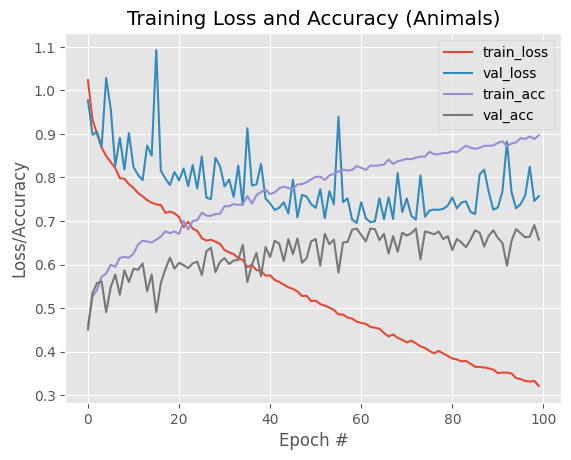

In [8]:
# Bước 3.3: Đánh giá mô hình và vẽ biểu đồ loss/accuracy
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt

print("[INFO] evaluating network...")
predictions = model_animals.predict(testX, batch_size=32)
print(classification_report(
    testY.argmax(axis=1),
    predictions.argmax(axis=1),
    target_names=["cat", "dog", "panda"],
))

# Vẽ biểu đồ training loss/accuracy
EPOCHS = 100
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, EPOCHS), H_animals.history["loss"], label="train_loss")
plt.plot(np.arange(0, EPOCHS), H_animals.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, EPOCHS), H_animals.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, EPOCHS), H_animals.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy (Animals)")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()
plt.show()

# Phân tích (điền sau khi quan sát biểu đồ):
# - Vùng epoch nào loss dao động mạnh? (thường do learning rate hơi cao)
# - Train/val loss có phân kỳ (overfitting) không, bắt đầu từ epoch nào?
# - So sánh accuracy đạt được (~71% theo tài liệu) với baseline neural network thường (~59%)


## Phần 4: Thực Hành với Bộ Dữ Liệu CIFAR-10

### Bước 4.1: Chuẩn bị dữ liệu CIFAR-10
- **Tham khảo**: Trang 10-11, mục 12.2.3
- Dùng `cifar10.load_data()`, chuẩn hóa về [0,1], one-hot encode nhãn, khởi tạo tên class.


In [9]:
# Bước 4.1: Nạp và tiền xử lý dữ liệu CIFAR-10
from tensorflow.keras.datasets import cifar10

print("[INFO] loading CIFAR-10 data...")
((trainX_c, trainY_c), (testX_c, testY_c)) = cifar10.load_data()
trainX_c = trainX_c.astype("float") / 255.0
testX_c = testX_c.astype("float") / 255.0

lb_cifar = LabelBinarizer()
trainY_c = lb_cifar.fit_transform(trainY_c)
testY_c = lb_cifar.transform(testY_c)

labelNames = ["airplane", "automobile", "bird", "cat", "deer",
              "dog", "frog", "horse", "ship", "truck"]

print("[INFO] trainX_c shape:", trainX_c.shape, "| testX_c shape:", testX_c.shape)


[INFO] loading CIFAR-10 data...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1990s 12us/step
[INFO] trainX_c shape: (50000, 32, 32, 3) | testX_c shape: (10000, 32, 32, 3)


### Bước 4.2: Điều chỉnh mô hình cho CIFAR-10
- **Tham khảo**: Trang 11
- Learning rate = 0.01, classes = 10, 40 epochs


In [10]:
# Bước 4.2: Compile và huấn luyện ShallowNet trên CIFAR-10
print("[INFO] compiling model...")
opt_c = SGD(learning_rate=0.01)
model_cifar = ShallowNet.build(width=32, height=32, depth=3, classes=10)
model_cifar.compile(loss="categorical_crossentropy", optimizer=opt_c, metrics=["accuracy"])

print("[INFO] training network...")
H_cifar = model_cifar.fit(
    trainX_c, trainY_c,
    validation_data=(testX_c, testY_c),
    batch_size=32,
    epochs=40,
    verbose=1,
)

# Lý do điều chỉnh hyperparameters:
# - Learning rate tăng lên 0.01 (so với 0.005 ở Animals) vì CIFAR-10 có nhiều dữ liệu
#   và nhiều lớp hơn, cần tốc độ học nhanh hơn để hội tụ trong số epoch giới hạn (40).
# - classes=10 vì CIFAR-10 có 10 lớp thay vì 3 lớp như Animals.


[INFO] compiling model...
[INFO] training network...


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.3585 - loss: 1.8197 - val_accuracy: 0.4148 - val_loss: 1.6668
Epoch 2/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4514 - loss: 1.5795 - val_accuracy: 0.4641 - val_loss: 1.5124
Epoch 3/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4955 - loss: 1.4469 - val_accuracy: 0.5016 - val_loss: 1.4073
Epoch 4/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5253 - loss: 1.3579 - val_accuracy: 0.5318 - val_loss: 1.3371
Epoch 5/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5508 - loss: 1.2854 - val_accuracy: 0.5376 - val_loss: 1.2960
Epoch 6/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5705 - loss: 1.2339 - val_accuracy: 0.5317 - val_loss: 1.3041
Epoch 7/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5850 - loss: 1.1950 - val_accuracy: 0.5480 - val_loss: 1.2720
Epoch 8/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5950 - loss: 1.1625 - 

### Bước 4.3: Phân tích kết quả CIFAR-10
- **Tham khảo**: Trang 11-13
- Đánh giá accuracy (60% vs 57% trước đó), phân tích overfitting, so sánh CPU/GPU.


[INFO] evaluating network...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

    airplane       0.63      0.59      0.61      1000
  automobile       0.81      0.61      0.70      1000
        bird       0.47      0.42      0.44      1000
         cat       0.53      0.25      0.34      1000
        deer       0.58      0.39      0.47      1000
         dog       0.48      0.52      0.50      1000
        frog       0.57      0.81      0.67      1000
       horse       0.58      0.70      0.64      1000
        ship       0.63      0.79      0.70      1000
       truck       0.58      0.75      0.65      1000

    accuracy                           0.58     10000
   macro avg       0.59      0.58      0.57     10000
weighted avg       0.59      0.58      0.57     10000



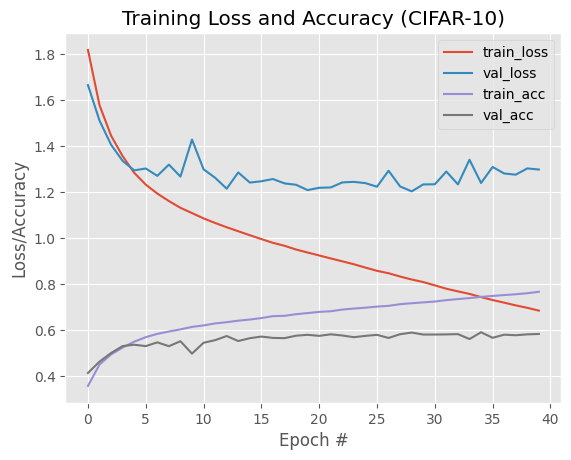

In [11]:
# Bước 4.3: Đánh giá và vẽ biểu đồ cho CIFAR-10
print("[INFO] evaluating network...")
predictions_c = model_cifar.predict(testX_c, batch_size=32)
print(classification_report(
    testY_c.argmax(axis=1),
    predictions_c.argmax(axis=1),
    target_names=labelNames,
))

EPOCHS_C = 40
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, EPOCHS_C), H_cifar.history["loss"], label="train_loss")
plt.plot(np.arange(0, EPOCHS_C), H_cifar.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, EPOCHS_C), H_cifar.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, EPOCHS_C), H_cifar.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy (CIFAR-10)")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()
plt.show()

# Nhận xét (điền sau khi quan sát kết quả thực tế):
# - Độ chính xác đạt được so với baseline (~60% vs ~57% theo tài liệu)
# - Train/val loss phân kỳ từ epoch nào -> dấu hiệu overfitting
# - CIFAR-10 khó hơn Animals do nhiều lớp hơn, ảnh độ phân giải thấp (32x32),
#   và số lượng mẫu mỗi lớp giới hạn -> dễ overfit hơn.
# - So sánh thời gian huấn luyện CPU vs GPU (ghi lại thời gian mỗi epoch khi chạy thực tế).


## Phần 5: Câu Hỏi Tự Đánh Giá

### Câu hỏi lý thuyết

1. **Tại sao ShallowNet chỉ dùng một lớp CONV nhưng vẫn hiệu quả hơn neural network thường?**
   Lớp CONV học được các đặc trưng cục bộ (local patterns: cạnh, màu sắc, kết cấu) trực tiếp
   từ ảnh 2D nhờ cơ chế chia sẻ trọng số (weight sharing) và trường tiếp nhận cục bộ (local
   receptive field), trong khi mạng feedforward thường phải "duỗi phẳng" ảnh thành vector 1D
   ngay từ đầu, làm mất hoàn toàn thông tin không gian giữa các pixel lân cận. Vì vậy dù chỉ có
   một lớp CONV, ShallowNet vẫn khai thác được cấu trúc không gian của ảnh tốt hơn.

2. **Ý nghĩa của việc dùng "same" padding trong Conv2D?**
   "same" padding thêm các pixel đệm (thường là 0) quanh biên ảnh đầu vào sao cho kích thước
   không gian (width, height) của feature map đầu ra bằng với kích thước đầu vào. Điều này giúp
   không bị mất thông tin ở viền ảnh và dễ kiểm soát kích thước qua các lớp mạng sâu hơn.

3. **Nguyên nhân gây overfitting trong cả hai thí nghiệm?**
   - Kiến trúc chỉ có 1 lớp CONV nên khả năng biểu diễn (representational capacity) tương đối
     hạn chế nhưng vẫn có thể "học thuộc" các mẫu huấn luyện nếu dữ liệu ít.
   - Số lượng dữ liệu huấn luyện nhỏ (Animals ~2250 ảnh train) hoặc độ phân giải thấp, ít đa
     dạng (CIFAR-10 32x32).
   - Không áp dụng các kỹ thuật chống overfitting như regularization, dropout, data augmentation.
   - Learning rate tương đối cao gây dao động lớn trong quá trình huấn luyện.



[INFO] Huấn luyện với learning rate = 0.001


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  -> val_accuracy sau 20 epochs: 0.5693

[INFO] Huấn luyện với learning rate = 0.005
  -> val_accuracy sau 20 epochs: 0.6173

[INFO] Huấn luyện với learning rate = 0.01
  -> val_accuracy sau 20 epochs: 0.6040

[INFO] Huấn luyện với learning rate = 0.05
  -> val_accuracy sau 20 epochs: 0.6453


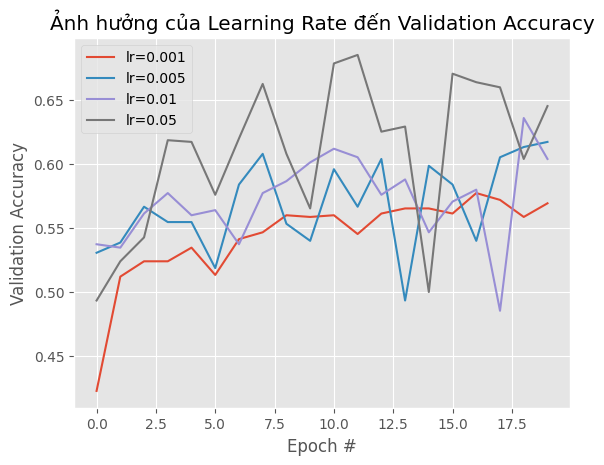

In [12]:
# Câu hỏi thực hành 1: Thay đổi learning rate và quan sát ảnh hưởng
learning_rates = [0.001, 0.005, 0.01, 0.05]
lr_histories = {}

for lr in learning_rates:
    print(f"\n[INFO] Huấn luyện với learning rate = {lr}")
    opt_lr = SGD(learning_rate=lr)
    m = ShallowNet.build(width=32, height=32, depth=3, classes=3)
    m.compile(loss="categorical_crossentropy", optimizer=opt_lr, metrics=["accuracy"])
    h = m.fit(
        trainX, trainY,
        validation_data=(testX, testY),
        batch_size=32,
        epochs=20,          # giảm epoch để so sánh nhanh
        verbose=0,
    )
    lr_histories[lr] = h.history
    final_val_acc = h.history["val_accuracy"][-1]
    print(f"  -> val_accuracy sau 20 epochs: {final_val_acc:.4f}")

# So sánh trực quan
plt.style.use("ggplot")
plt.figure()
for lr, hist in lr_histories.items():
    plt.plot(hist["val_accuracy"], label=f"lr={lr}")
plt.title("Ảnh hưởng của Learning Rate đến Validation Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

# Nhận xét: learning rate quá cao -> dao động mạnh/khó hội tụ;
# learning rate quá thấp -> hội tụ chậm, cần nhiều epoch hơn.


In [13]:
# Câu hỏi thực hành 2: Thử nghiệm số lượng filters khác nhau (16, 32, 64)
from tensorflow.keras.models import Sequential as _Sequential
from tensorflow.keras.layers import Conv2D as _Conv2D


def build_shallownet_variable_filters(width, height, depth, classes, num_filters):
    model = _Sequential()
    inputShape = (height, width, depth)
    if K.image_data_format() == "channels_first":
        inputShape = (depth, height, width)

    model.add(_Conv2D(num_filters, (3, 3), padding="same", input_shape=inputShape))
    model.add(Activation("relu"))
    model.add(Flatten())
    model.add(Dense(classes))
    model.add(Activation("softmax"))
    return model


filter_options = [16, 32, 64]
filter_results = {}

for nf in filter_options:
    print(f"\n[INFO] Huấn luyện với số filters = {nf}")
    opt_f = SGD(learning_rate=0.005)
    m = build_shallownet_variable_filters(32, 32, 3, 3, num_filters=nf)
    m.compile(loss="categorical_crossentropy", optimizer=opt_f, metrics=["accuracy"])
    h = m.fit(
        trainX, trainY,
        validation_data=(testX, testY),
        batch_size=32,
        epochs=20,
        verbose=0,
    )
    final_val_acc = h.history["val_accuracy"][-1]
    filter_results[nf] = final_val_acc
    print(f"  -> val_accuracy sau 20 epochs: {final_val_acc:.4f}")

print("\n[INFO] Tổng hợp kết quả theo số filters:")
for nf, acc in filter_results.items():
    print(f"  filters={nf}: val_accuracy={acc:.4f}")

# Nhận xét: nhiều filters hơn -> mô hình học được nhiều đặc trưng hơn nhưng cũng dễ overfit hơn
# và tốn nhiều tài nguyên tính toán hơn; cần cân bằng giữa độ phức tạp và dữ liệu sẵn có.



[INFO] Huấn luyện với số filters = 16


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  -> val_accuracy sau 20 epochs: 0.6280

[INFO] Huấn luyện với số filters = 32
  -> val_accuracy sau 20 epochs: 0.5880

[INFO] Huấn luyện với số filters = 64
  -> val_accuracy sau 20 epochs: 0.5627

[INFO] Tổng hợp kết quả theo số filters:
  filters=16: val_accuracy=0.6280
  filters=32: val_accuracy=0.5880
  filters=64: val_accuracy=0.5627


In [14]:
# Câu hỏi thực hành 3: Điều chỉnh batch_size và đánh giá tác động
batch_sizes = [16, 32, 64, 128]
batch_results = {}

for bs in batch_sizes:
    print(f"\n[INFO] Huấn luyện với batch_size = {bs}")
    opt_b = SGD(learning_rate=0.005)
    m = ShallowNet.build(width=32, height=32, depth=3, classes=3)
    m.compile(loss="categorical_crossentropy", optimizer=opt_b, metrics=["accuracy"])
    h = m.fit(
        trainX, trainY,
        validation_data=(testX, testY),
        batch_size=bs,
        epochs=20,
        verbose=0,
    )
    final_val_acc = h.history["val_accuracy"][-1]
    batch_results[bs] = final_val_acc
    print(f"  -> val_accuracy sau 20 epochs: {final_val_acc:.4f}")

print("\n[INFO] Tổng hợp kết quả theo batch_size:")
for bs, acc in batch_results.items():
    print(f"  batch_size={bs}: val_accuracy={acc:.4f}")

# Nhận xét: batch_size nhỏ -> cập nhật trọng số thường xuyên hơn, có thể hội tụ tốt hơn
# nhưng huấn luyện chậm hơn (nhiều bước/epoch); batch_size lớn -> huấn luyện nhanh hơn
# (tận dụng tốt phần cứng) nhưng có thể cần learning rate lớn hơn để đạt cùng độ chính xác.



[INFO] Huấn luyện với batch_size = 16
  -> val_accuracy sau 20 epochs: 0.5787

[INFO] Huấn luyện với batch_size = 32
  -> val_accuracy sau 20 epochs: 0.5933

[INFO] Huấn luyện với batch_size = 64
  -> val_accuracy sau 20 epochs: 0.5827

[INFO] Huấn luyện với batch_size = 128
  -> val_accuracy sau 20 epochs: 0.5653

[INFO] Tổng hợp kết quả theo batch_size:
  batch_size=16: val_accuracy=0.5787
  batch_size=32: val_accuracy=0.5933
  batch_size=64: val_accuracy=0.5827
  batch_size=128: val_accuracy=0.5653
